In [1]:
import os
# see: https://docs.nvidia.com/deeplearning/frameworks/tensorflow-user-guide/index.html
# use async memory allocator (added to avoid some oom errors)
os.environ['TF_GPU_ALLOCATOR']='cuda_malloc_async'
# and turn off debugging info
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'

import tensorflow as tf  # noqa: E402
import keras_tuner as kt  # noqa: E402
import math  # noqa: E402

from load_data import load_datasets  # noqa: E402
from helper_functions import display_samples,serialise_hpsearch  # noqa: E402
from hyperparameter_search import CustomHyperModel  # noqa: E402

# some magic functions
%matplotlib inline

# we want to use mixed precision so
tf.keras.mixed_precision.set_global_policy(tf.keras.mixed_precision.Policy('mixed_float16'))

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3090, compute capability 8.6


In [2]:
# first set some initial data up
dataset_path='datasets/130kv2/'
class_map = {0:"Original", 1:"Poisoned"}

# we won't be varying the batch size yet so set this here too
batch_size=32

Generating preview for dataset 'train' located in 'datasets/130kv2/':


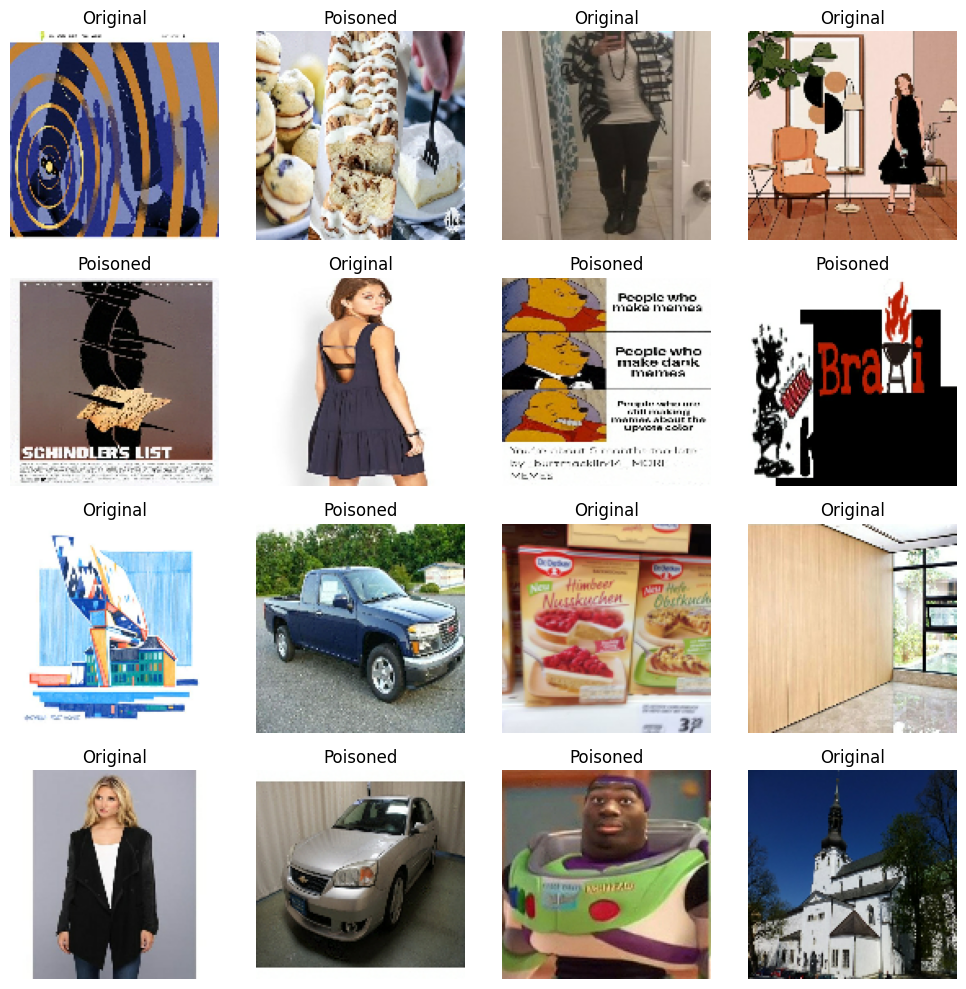

In [3]:
# let's test loading our training, validation and test datasets by generating a preview using resize and a resolution of 256*256
ds = load_datasets(dataset_path, class_map, batch_size, 128, False)

for name, data in ds.items():
    print(f"Generating preview for dataset '{name}' located in '{dataset_path}':")
    display_samples(data.unbatch(),class_map)
    break

In [4]:
# we don't want to have to retype all this for each trial so we need something that can be called for various hp search algorithms, image sizes and resizing methods
def run_trials(search_algo, image_size, crop_and_pad):
    """
    For a given hyperparameter optimisation algorithm, desired image size and resizing method will run a hyperparameter search and save the results to the models\search_results folder.
    
    Results will be stored in csv format with name in format "{search_algo}_size{image_size}_crop{crop_and_pad}.csv".

    Args:
        search_algo (string): which hyperparameter search algorithm to use, either 'bayesopt' or 'hyperband'
        epochs (int): maximum number of epochs to run each trial for
        image_size (int): maximum height/width of the images
        crop_and_pad (bool): whether to crop and pad images, if not they will be resized if height/width of sample differs to image_size
    """
    # load the data first
    ds = load_datasets(dataset_path, class_map, batch_size, image_size, crop_and_pad)
    
    # now create the name for this search, which we'll use to save progress in the autotune folder and serialise the results at the end
    trial_name = f"{search_algo}_size{image_size}_crop{crop_and_pad}"
    
    # lets set up a few tuners
    if search_algo == "bayesopt":
        # we want to set max_epochs on a per-algo basis as we can go a bit higher with hyperband
        max_epochs=15
        tuner = kt.BayesianOptimization(
            hypermodel=CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
            objective='val_accuracy',
            max_trials=30,
            max_model_size=2.5e6, # added this to try and avoid us ending up with oversized models and OOM errors
            # num_initial_points defaults to 3x the dimensionality of the model, that's 36 trials in our case!
            # Anything lower than this would essentially be random search, so we've set it to a somewhat lower value
            num_initial_points=15,
            alpha=1e-3,
            beta=3.,
            seed=123,
            max_retries_per_trial=1, # we'll retry once but these are probably memory errors
            max_consecutive_failed_trials=50,
            directory='autotune',
            project_name=trial_name
        )
    elif search_algo == "hyperband":
        # we'll double max_epochs to 30 here, as it will only go this high on the best performing trials
        max_epochs=30
        tuner = kt.Hyperband(
            CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2),
            objective='val_accuracy',
            max_epochs=max_epochs,
            max_model_size=2.5e6, # added this to try and avoid us ending up with oversized models and OOM errors
            factor=3,
            hyperband_iterations=1,
            seed=123,
            max_retries_per_trial=1, # we'll retry once but these are probably memory errors
            max_consecutive_failed_trials=50, # skipped trials due to model size count toward this!
            directory='autotune',
            project_name=trial_name
        )

    # set up the callback for early stopping
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=1e-3, patience=5)
    ]

    # and then begin the search
    tuner.search(
        ds['train'],
        epochs=max_epochs,
        callbacks=[callbacks],
        validation_data=ds['validation'],
    )

    # lastly we'll save the top 5 results to file
    serialise_hpsearch(tuner,num_to_save=5)

Before running anything we want to check how long it's going to take and tweak until we're expecting runtime <48 hours. This likely a pessimistic estimate due to our use of early stopping and skipping over large models.

We have six different searches to run, three with hyperband and three with bayesian optimisation so we calculate how long they'll take approximately with the below then tweak values as required.

In [5]:
# each trial is being run three times so multiply results for both by this figure
num_searches=3

# bayesian optimisation
# https://keras.io/api/keras_tuner/tuners/bayesian/#bayesianoptimization-class
max_epochs=15
max_trials=30
expected_epochs=max_epochs*max_trials*num_searches
runtime_seconds=expected_epochs*60

print(f"Bayesian optimisation will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

# hyperband
# see https://keras.io/api/keras_tuner/tuners/hyperband/#hyperband-class
max_epochs=30
factor=3
iterations=1
expected_epochs=max_epochs * (math.log(max_epochs, factor) ** 2) * iterations * num_searches
runtime_seconds=expected_epochs*60

print(f"\nHyperband will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

Bayesian optimisation will run for a maximum of 1350 epochs.
This is expected to take no more than 22.5 hours.

Hyperband will run for a maximum of 862.6155375380157 epochs.
This is expected to take no more than 14.376925625633595 hours.


Now we've got a method for running trials, and a reasonable estimate for the time frame, we want to create a combination of searches we can run.

For completeness we want to test:

• bayesopt + hyperband

• sample sizes of either 512x512 or 256x256

• resizing methods of either crop and pad or resize via nearest neighbour

Since the source data is not cropped, padded or resized if the desired image size is the same as the source data we also want to avoid testing both crop and pad and resize for 512x512 images!

In [6]:
# first create tuples of all the possible settings
algos = ('bayesopt','hyperband')
sizes = (512,256)
resize_methods = (True, False)

# now create a list of dicts representing every possible combination
possible_params = [
    {"search_algo":a, "image_size":s, "crop_and_pad":r}
        for a in algos
        for s in sizes
        for r in resize_methods
]

# remove the redundant cases
possible_params = [x for x in possible_params if not (x["image_size"] == 512 and not x["crop_and_pad"])]

# print a few and check the number of entries to check we're on the right path
print(possible_params[:2])
print(len(possible_params))

[{'search_algo': 'bayesopt', 'image_size': 512, 'crop_and_pad': True}, {'search_algo': 'bayesopt', 'image_size': 256, 'crop_and_pad': True}]
6


In [7]:
# before running anything we want to check how long it's going to take and tweak until we're expecting runtime <24 hours
# we have six different searches to run, three with hyperband and three with bayesian optimisation

# hyperband
# see https://keras.io/api/keras_tuner/tuners/hyperband/#hyperband-class
max_epochs=30
factor=3
iterations=1
num_searches=3
expected_epochs=max_epochs * (math.log(max_epochs, factor) ** 2) * iterations * num_searches
runtime_seconds=expected_epochs*60

print(f"Hyperband will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

# bayesian optimisation
# see https://keras.io/api/keras_tuner/tuners/hyperband/#hyperband-class
max_epochs=15
max_trials=30
num_searches=3
expected_epochs=max_epochs*max_trials*num_searches
runtime_seconds=expected_epochs*60

print(f"\nBayesian optimisation will run for a maximum of {expected_epochs} epochs.")
print(f"This is expected to take no more than {runtime_seconds/60/60} hours.")

Hyperband will run for a maximum of 862.6155375380157 epochs.
This is expected to take no more than 14.376925625633595 hours.

Bayesian optimisation will run for a maximum of 1350 epochs.
This is expected to take no more than 22.5 hours.


In [8]:
# now we can run our trials
for params in possible_params:
    run_trials(**params)


Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
2e-08             |2e-08             |learning_rate
True              |True              |aug_norm
True              |True              |aug_flip
0.2               |0.2               |aug_rotate
8                 |8                 |conv1_size
True              |True              |residual_connections
2                 |2                 |midblock_repetitions
512               |512               |midblock_1_size
384               |384               |midblock_2_size
1024              |1024              |final_conv_size
0.2               |0.2               |dropout

Epoch 1/15


I0000 00:00:1715288763.599816    2880 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  1/193 [..............................] - ETA: 1:13:17 - loss: 0.9990 - accuracy: 0.3438

Now we can load the results, select the best model and retrain it for evaluation.

In [ ]:
image_size = 512
model_builder = CustomHyperModel(input_shape=(image_size,image_size) + (3,), num_classes=2)

In [ ]:
"""
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
]
model_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
).history
"""

In [ ]:
"""
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)
#model_history
"""